In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename

In [13]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = False
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [14]:
hfile

'../data/mms1_brst_f_e_0.25_20151209_050355_050359.h5'

In [15]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    bvec_lmn = f["lmn"]["bvec"][:]
    evec_lmn = f["lmn"]["evec_lor"][:]
    evec_fac = f["fac"]["evec_lor"][:]
    jdotE_fac = f["fac"]["jdotE_fac"][:]
    vdf_vol_fac = f["fac"]["bvdf_vol"][...]
    c_vol_fac = f["fac"]["c_vol"][...]
    cz_folds_fac = f["fac"]["cz_folds"][...]
    x_fac = f["fac"]["binc_n"][:]
    y_fac = f["fac"]["binc_n"][:]
    z_fac = f["fac"]["binc_n"][:] 
    vv_fac = f["fac"]["vv"][:] 

In [16]:
ntime.shape, bvec_lmn.shape, evec_lmn.shape, evec_fac.shape, jdotE_fac.shape

((133,), (133, 3), (133, 3), (133, 3), (133, 4))

# Reconnection Window Plot

In [17]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

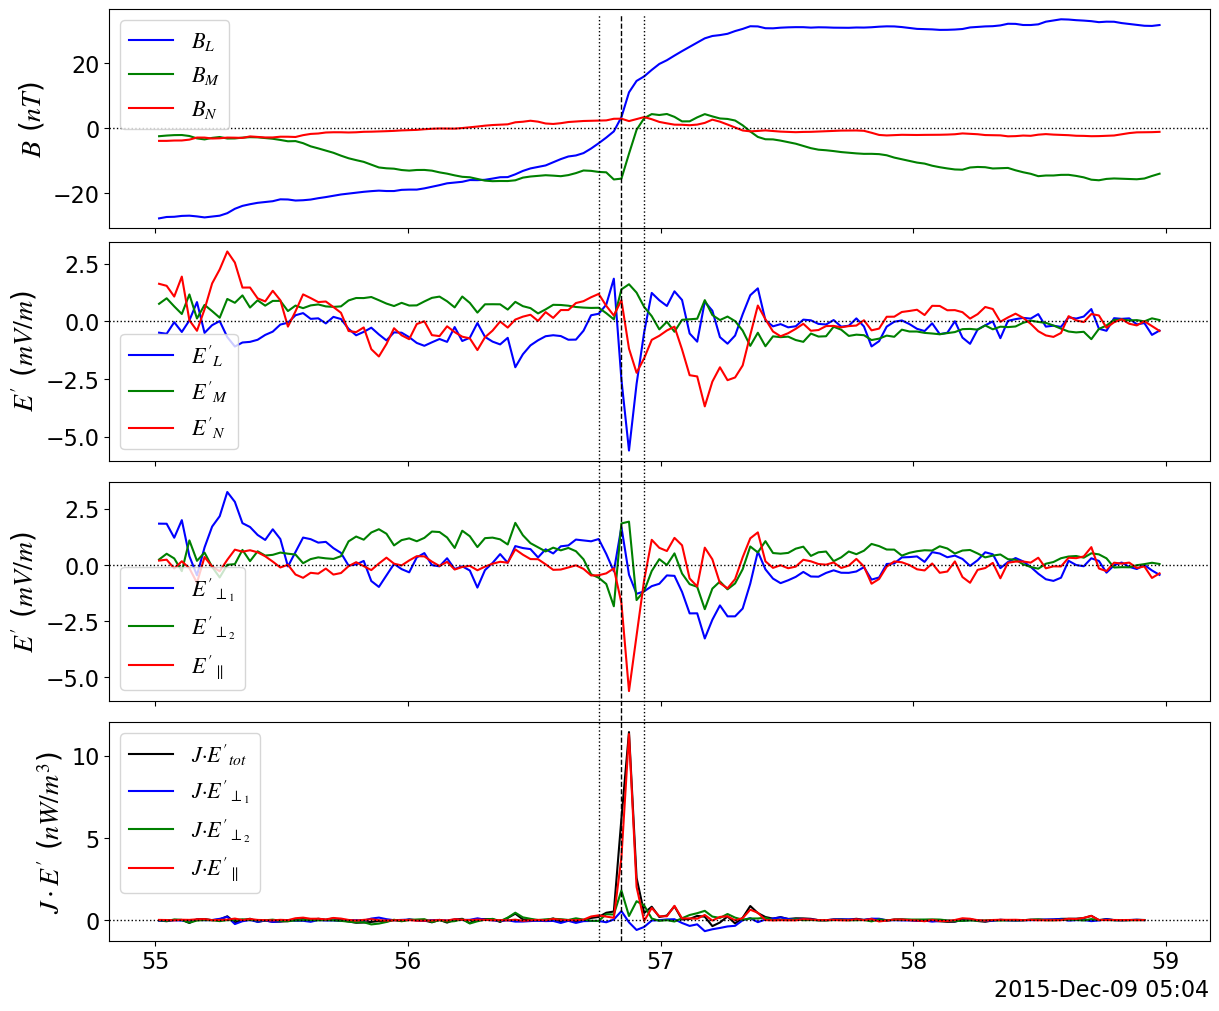

In [18]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 20   # adjust as needed
tick_fntsz = 16
legend_fntsz = 16
legendFrame = True

fig, ax = plt.subplots(4,1, figsize=(12, 10), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r"$E'_{\perp_1}$", r"$E'_{\perp_2}$", 
        r"$E'_{\parallel}$"])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

for axis in ax:
    axis.tick_params(axis='both', which='major', labelsize=tick_fntsz)
    axis.xaxis.get_offset_text().set_fontsize(tick_fntsz)  # Scales the date string

# Vertical reference lines
y_up = 4 + 0.228
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)

plt.show()

## Adding plasma beta and density to the plot

In [11]:
mms.fgm(trange=trange, probe=probe, data_rate=data_rate, level=level,
        varnames='mms1_fgm_b_gse_brst_l2', time_clip=True, 
        get_support_data=get_support_data, no_update=no_update)
tplot_rename('mms1_fgm_b_gse_brst_l2', 'bvec_gse')

06-Aug-26 15:26:56: Searching for local files...
06-Aug-26 15:26:56: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf
06-Aug-26 15:26:56: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
06-Aug-26 15:26:56: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


In [12]:
mms.fpi(trange= trange, probe=probe, data_rate=data_rate, level='l2',
        datatype=['des-moms', 'dis-moms'], time_clip=True, 
        varnames=['mms1_des_numberdensity_brst', 'mms1_dis_numberdensity_brst', 
        'mms1_des_temppara_brst', 'mms1_des_tempperp_brst', 
        'mms1_dis_temppara_brst', 'mms1_dis_tempperp_brst'], 
        get_support_data=True, no_update=True)
tplot_rename('mms1_des_numberdensity_brst', 'den_e')
tplot_rename('mms1_dis_numberdensity_brst', 'den_i')
tplot_rename('mms1_des_temppara_brst', 'tpara_e')
tplot_rename('mms1_des_tempperp_brst', 'tperp_e')
tplot_rename('mms1_dis_temppara_brst', 'tpara_i')
tplot_rename('mms1_dis_tempperp_brst', 'tperp_i')

06-Aug-26 15:26:57: Searching for local files...
06-Aug-26 15:26:57: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:26:57: Searching for local files...
06-Aug-26 15:26:57: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:26:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
06-Aug-26 15:26:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:26:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
06-Aug-26 15:26:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:26:57: The name mms1_des_errorflags_brst is currently n

In [13]:
fpc.downsample_cad('bvec_gse', 'den_e', trange, newname='bvec_ds')
fpc.upsample_cad('den_i', 'den_e', newname='den_i_us')

06-Aug-26 15:26:58: avg_data was applied to: bvec_ds
06-Aug-26 15:26:58: tinterpol (linear) was applied to: den_i_us


'den_i_us'

In [19]:
_, den_e = get_data('den_e')
_, den_i = get_data('den_i_us')
_, bvec_gse = get_data('bvec_ds')
_, tpara_e = get_data('tpara_e')
_, tperp_e = get_data('tperp_e')
_, tpara_i = get_data('tpara_i')
_, tperp_i = get_data('tperp_i')
bmag = bvec_gse[:, 3]

In [20]:
beta_par_e, beta_perp_e, beta_scalar_e, ntime_e = fpc.compute_beta_profiles(trange)

06-Aug-26 15:28:01: Searching for local files...
06-Aug-26 15:28:01: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:28:01: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
06-Aug-26 15:28:01: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:28:01: The name mms1_des_errorflags_brst is currently not in pyspedas
06-Aug-26 15:28:01: The name mms1_des_compressionloss_brst is currently not in pyspedas
06-Aug-26 15:28:01: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
06-Aug-26 15:28:01: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
06-Aug-26 15:28:01: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
06-Aug-26 15:28:01: The name mms1_des_errorflags_brst_moms is currently not in pyspedas
0

In [21]:
beta_par_i, beta_perp_i, beta_scalar_i, ntime_i = fpc.compute_beta_profiles(trange, species='i')

06-Aug-26 15:28:04: Searching for local files...
06-Aug-26 15:28:04: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:28:04: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
06-Aug-26 15:28:04: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:28:04: The name mms1_dis_errorflags_brst is currently not in pyspedas
06-Aug-26 15:28:04: The name mms1_dis_compressionloss_brst is currently not in pyspedas
06-Aug-26 15:28:04: The name mms1_dis_pitchangdist_lowen_brst is currently not in pyspedas
06-Aug-26 15:28:04: The name mms1_dis_pitchangdist_miden_brst is currently not in pyspedas
06-Aug-26 15:28:04: The name mms1_dis_pitchangdist_highen_brst is currently not in pyspedas
06-Aug-26 15:28:04: The name mms1_dis_errorflags_brst_moms is currently not in pyspedas
0

In [22]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

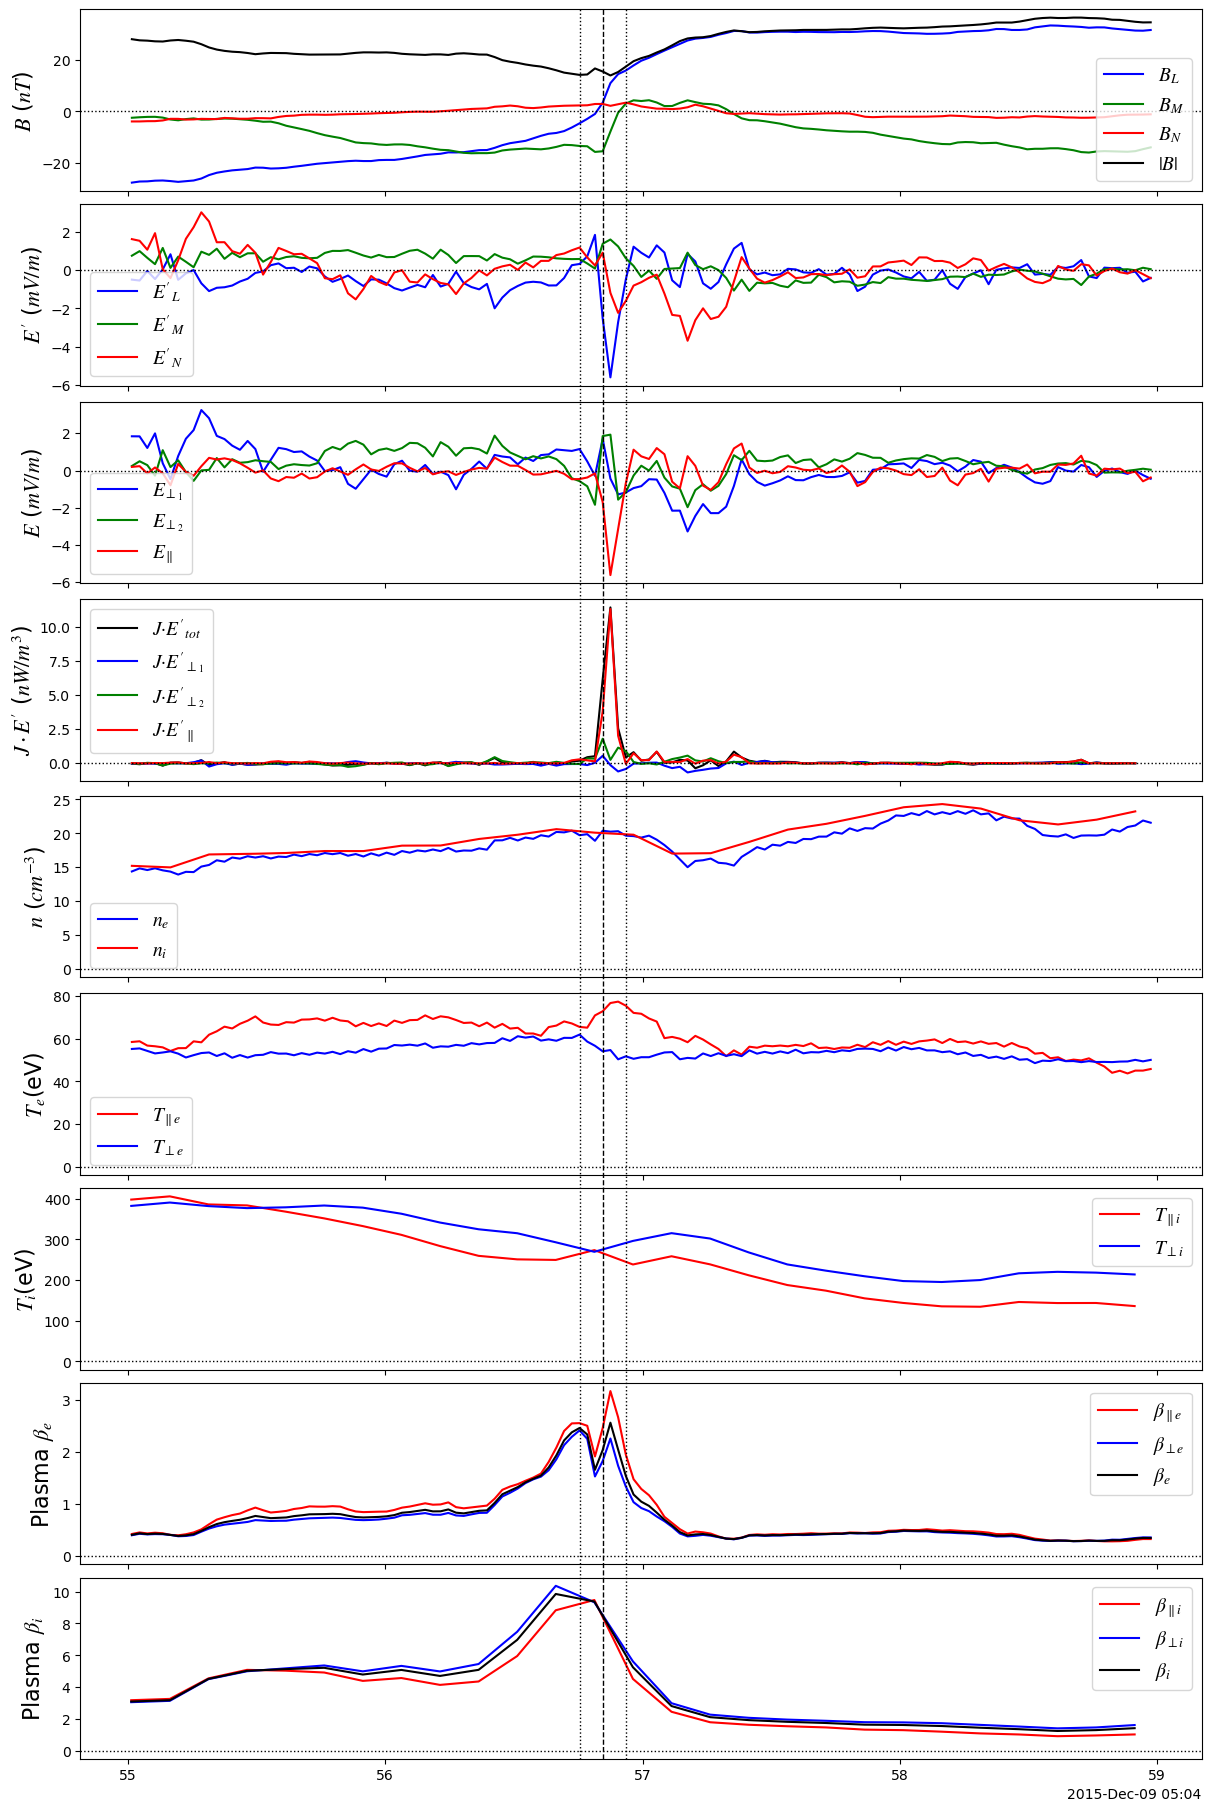

In [23]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 9
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 18), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r'$E_{\perp_1}$', r'$E_{\perp_2}$', 
        r'$E_{\parallel}$'])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel('$E$ ($mV/m$)', fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

# Fifth subplot: ion and electron density
ax[4].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[4].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[4].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Sixth subplot: electron temp profiles
ax[5].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[5].plot(t_ax, tpara_e, linewidth=1.5, label=r'$T_{\parallel e}$')
ax[5].plot(t_ax, tperp_e, linewidth=1.5, label=r'$T_{\perp e}$')
ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[5].set_ylabel(r'$T_e$(eV)', fontsize=axs_label_fntsz)
ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Seventh subplot: ion temp profiles
t_axi = time_datetime(ntime_i)
ax[6].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[6].plot(t_axi, tpara_i, linewidth=1.5, label=r'$T_{\parallel i}$')
ax[6].plot(t_axi, tperp_i, linewidth=1.5, label=r'$T_{\perp i}$')
ax[6].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[6].set_ylabel(r'$T_i$(eV)', fontsize=axs_label_fntsz)
ax[6].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Eighth subplot: electron beta profiles
ax[7].set_prop_cycle(color=['red', 'blue', 'black']) # custom color cycle
ax[7].plot(t_ax, beta_par_e, linewidth=1.5, label=r'$\beta_{\parallel e}$')
ax[7].plot(t_ax, beta_perp_e, linewidth=1.5, label=r'$\beta_{\perp e}$')
ax[7].plot(t_ax, beta_scalar_e, linewidth=1.5, label=r'$\beta_{e}$')
ax[7].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[7].set_ylabel(r'Plasma $\beta_e$', fontsize=axs_label_fntsz)
ax[7].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Ninth subplot: ion beta profiles
ax[8].set_prop_cycle(color=['red', 'blue', 'black']) # custom color cycle
ax[8].plot(t_axi, beta_par_i, linewidth=1.5, label=r'$\beta_{\parallel i}$')
ax[8].plot(t_axi, beta_perp_i, linewidth=1.5, label=r'$\beta_{\perp i}$')
ax[8].plot(t_axi, beta_scalar_i, linewidth=1.5, label=r'$\beta_{i}$')
ax[8].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[8].set_ylabel(r'Plasma $\beta_i$', fontsize=axs_label_fntsz)
ax[8].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

## Adding velocities to the plot

In [34]:
fpi_vars = mms.fpi(trange=trange, datatype=['des-moms', 'dis-moms'], level='l2', 
                            data_rate='brst', varnames=['mms1_des_bulkv_gse_brst', 
                            'mms1_dis_bulkv_gse_brst'],
                            time_clip=True)

06-Aug-26 15:34:21: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
06-Aug-26 15:34:21: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:34:21: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
06-Aug-26 15:34:21: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
06-Aug-26 15:34:21: The name mms1_des_errorflags_brst is currently not in pyspedas
06-Aug-26 15:34:21: The name mms1_des_compressionloss_brst is currently not in pyspedas
06-Aug-26 15:34:21: The name mms1_dis_errorflags_brst is currently not in pyspedas
06-Aug-26 15:34:21: The name mms1_dis_compressionloss_brst is currently not in pyspedas
06-Aug-26 15:34:21: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
06-Aug-26 15:34:21: The name mm

In [35]:
pyspedas.tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')
pyspedas.tplot_rename('mms1_dis_bulkv_gse_brst', 'bulk_vi_gse')

In [26]:
with h5py.File(hfile, "r") as f:
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]

In [43]:
_, bulk_ve_gse = get_data('bulk_ve_gse')

In [49]:
fpc.upsample_cad('bulk_vi_gse', 'bulk_ve_gse', newname='bulk_vi_gse_up')

06-Aug-26 15:39:05: tinterpol (linear) was applied to: bulk_vi_gse_up


'bulk_vi_gse_up'

In [50]:
_, bulk_vi_gse = get_data('bulk_vi_gse_up')

In [28]:
bulk_ve_fac = np.einsum('tij, tj -> ti', fac_mat, bulk_ve_gse)

In [29]:
lmn_mat.shape

(1, 3, 3)

In [52]:
bulk_ve_lmn = np.einsum('ij, tj -> ti', lmn_mat[0], bulk_ve_gse)
bulk_vi_lmn = np.einsum('ij, tj -> ti', lmn_mat[0], bulk_vi_gse)

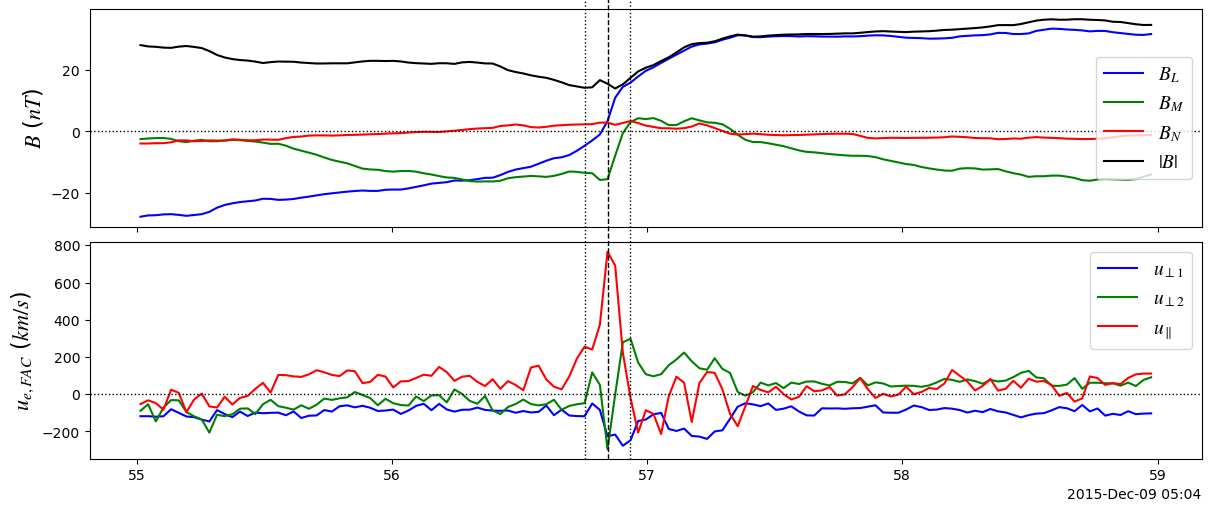

In [31]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 2
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 5), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, bulk_ve_fac, linewidth=1.5, label=[r"$u_{\perp 1}$", 
    r"$u_{\perp 2}$", r"$u_{\parallel}$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$u_{e, FAC}$ ($km/s$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)


# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

## *Adding other quantities to the plot

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename

In [3]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = True
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [4]:
hfile

'../data/mms1_brst_df_e_0.25_20151209_050355_050359.h5'

Reading in neccessary stuff from h5 save file

In [25]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    bvec_lmn = f["lmn"]["bvec"][:]
    evec_lmn = f["lmn"]["evec_lor"][:]
    evec_fac = f["fac"]["evec_lor"][:]
    jvec_lmn = f["lmn"]["jvec_lmn"][:]
    jvec_fac = f["fac"]["jvec_fac"][:]
    jdotE_fac = f["fac"]["jdotE_fac"][:]
    vdf_vol_fac = f["fac"]["bvdf_vol"][...]
    c_vol_fac = f["fac"]["c_vol"][...]
    x_fac = f["fac"]["binc_n"][:]
    y_fac = f["fac"]["binc_n"][:]
    z_fac = f["fac"]["binc_n"][:] 
    vv_fac = f["fac"]["vv"][:]
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]

Gathering all quantities for reconnection time window plots
1. Omnidirectional Energry Spectra of ions and electrons.
2. Number density profiles of ions and electrons.
3. Temperature profiles of ions and electrons.
4. Bulk-flows in LMN of both ions and electrons.
5. B-field in lmn with magnitude - already in .h5 file.
6. J-vector in fac and lmn - already in .h5 file.
6. E-field in fac and lmn - already in .h5 file.
7. J-dot-E in fac and lmn with magnitude - already in .h5 file.

In [6]:
# 2. bulk-flows in LMN of both ions and electrons
fpi_vars = mms.fpi(trange=trange, datatype=['des-moms', 'dis-moms'], level='l2', 
                        data_rate='brst', 
                        varnames=['mms1_des_energyspectr_omni_brst', 'mms1_dis_energyspectr_omni_brst',
                        'mms1_des_numberdensity_brst','mms1_dis_numberdensity_brst', 
                        'mms1_des_temppara_brst', 'mms1_dis_temppara_brst',
                        'mms1_des_tempperp_brst', 'mms1_dis_tempperp_brst',
                        'mms1_des_bulkv_gse_brst', 'mms1_dis_bulkv_gse_brst'],
                        time_clip=True)

10-Aug-26 16:11:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
10-Aug-26 16:11:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
10-Aug-26 16:11:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
10-Aug-26 16:11:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
10-Aug-26 16:11:57: The name mms1_des_errorflags_brst is currently not in pyspedas
10-Aug-26 16:11:57: The name mms1_des_compressionloss_brst is currently not in pyspedas
10-Aug-26 16:11:57: The name mms1_dis_errorflags_brst is currently not in pyspedas
10-Aug-26 16:11:57: The name mms1_dis_compressionloss_brst is currently not in pyspedas
10-Aug-26 16:11:57: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
10-Aug-26 16:11:57: The name mm

In [7]:
fpi_vars

['mms1_des_temppara_brst',
 'mms1_des_numberdensity_brst',
 'mms1_des_bulkv_gse_brst',
 'mms1_dis_temppara_brst',
 'mms1_des_tempperp_brst',
 'mms1_dis_bulkv_gse_brst',
 'mms1_dis_numberdensity_brst',
 'mms1_des_energyspectr_omni_brst',
 'mms1_dis_energyspectr_omni_brst',
 'mms1_dis_tempperp_brst',
 'mms1_des_errorflags_brst_moms',
 'mms1_des_compressionloss_brst_moms',
 'mms1_dis_errorflags_brst_moms',
 'mms1_dis_compressionloss_brst_moms']

In [8]:
tplot_rename('mms1_des_energyspectr_omni_brst', 'energy_e')
tplot_rename('mms1_dis_energyspectr_omni_brst', 'energy_i')
tplot_rename('mms1_des_numberdensity_brst', 'den_e')
tplot_rename('mms1_dis_numberdensity_brst', 'den_i')
tplot_rename('mms1_des_temppara_brst', 'te_para')
tplot_rename('mms1_dis_temppara_brst', 'ti_para')
tplot_rename('mms1_des_tempperp_brst', 'te_perp')
tplot_rename('mms1_dis_tempperp_brst', 'ti_perp')
tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')
tplot_rename('mms1_dis_bulkv_gse_brst', 'bulk_vi_gse')

In [9]:
with h5py.File(hfile, "r") as f:
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]

Matching the cadences of density and temp profiles to electron bulk flow

In [19]:
fpc.upsample_cad('energy_i', 'energy_e', newname='energy_i_up')

10-Aug-26 16:14:12: tinterpol (linear) was applied to: energy_i_up


'energy_i_up'

In [22]:
fpc.upsample_cad('den_i', 'den_e', newname='den_i_up')

10-Aug-26 16:18:55: tinterpol (linear) was applied to: den_i_up


'den_i_up'

In [23]:
fpc.upsample_cad('ti_para','te_para', newname='ti_para_up')

10-Aug-26 16:19:25: tinterpol (linear) was applied to: ti_para_up


'ti_para_up'

In [24]:
fpc.upsample_cad('ti_perp', 'te_perp', newname='ti_perp_up')

10-Aug-26 16:20:20: tinterpol (linear) was applied to: ti_perp_up


'ti_perp_up'

Matching the cadences of ion bulk flow to electron bulk flow

In [ ]:
fpc.upsample_cad('bulk_vi_gse', 'bulk_ve_gse', newname='bulk_vi_gse_up')

10-Aug-26 16:11:59: tinterpol (linear) was applied to: bulk_vi_gse_up


'bulk_vi_gse_up'

Rotating bulk flow into fac and lmn coordinates

In [ ]:
_, bulk_ve_gse = get_data('bulk_ve_gse')
_, bulk_vi_gse = get_data('bulk_vi_gse_up')

In [ ]:
_, bulk_ve_fac = fpc.rotate_to_fac(bulk_ve_gse, fac_mat)
_, bulk_vi_fac = fpc.rotate_to_fac(bulk_vi_gse, fac_mat)

Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!


In [ ]:
_, bulk_ve_lmn = fpc.rotate_to_lmn(bulk_ve_gse, lmn_mat)
_, bulk_vi_lmn = fpc.rotate_to_lmn(bulk_vi_gse, lmn_mat)

Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!


Plotting all of it for probe 1

In [33]:
# Extract the numpy arrays:
energy_e = get_data('energy_e').y

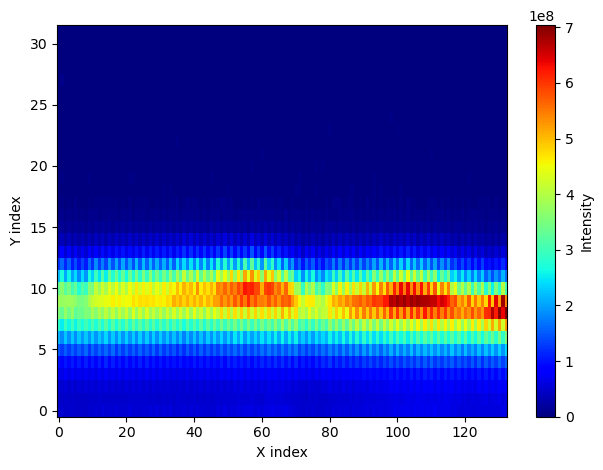

In [70]:
import matplotlib.pyplot as plt
arr = np.where(energy_e == -1e31, np.nan, energy_e)
plt.figure()
im = plt.imshow(arr.T, aspect='auto', origin='lower', cmap='jet')
plt.colorbar(im, label='Intensity')
plt.xlabel('X index')
plt.ylabel('Y index')
plt.tight_layout()
plt.show()

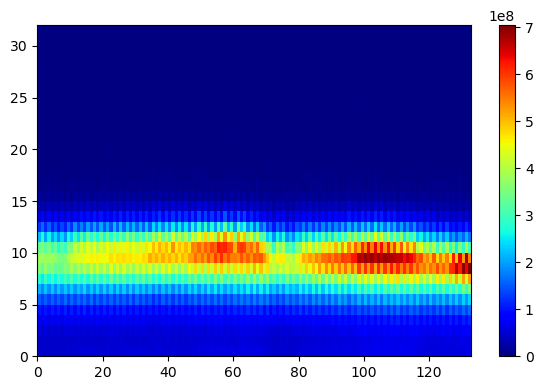

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
im = plt.pcolormesh(energy_e.T, cmap='jet', shading='auto')
plt.colorbar(im)
plt.tight_layout()
plt.show()


10-Aug-26 21:46:50: /opt/anaconda3/envs/phy/lib/python3.13/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),

10-Aug-26 21:46:50: /opt/anaconda3/envs/phy/lib/python3.13/ast.py:602: DeprecationWarning: Constant.__init__ got an unexpected keyword argument 's'. Support for arbitrary keyword arguments is deprecated and will be removed in Python 3.15.
  return Constant(*args, **kwargs)

10-Aug-26 21:46:50: /opt/anaconda3/envs/phy/lib/python3.13/ast.py:602: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)

10-Aug-26 21:46:50: /opt/anaconda3/envs/phy/lib/python3.13/ast.py:602: DeprecationWarning: Constant.__init__ missing 1 required positional argument: 'value'. This will become an error in Python 3.15.
  return Constant(*args, **kwargs)



AttributeError: 'Axes' object has no attribute 'get'

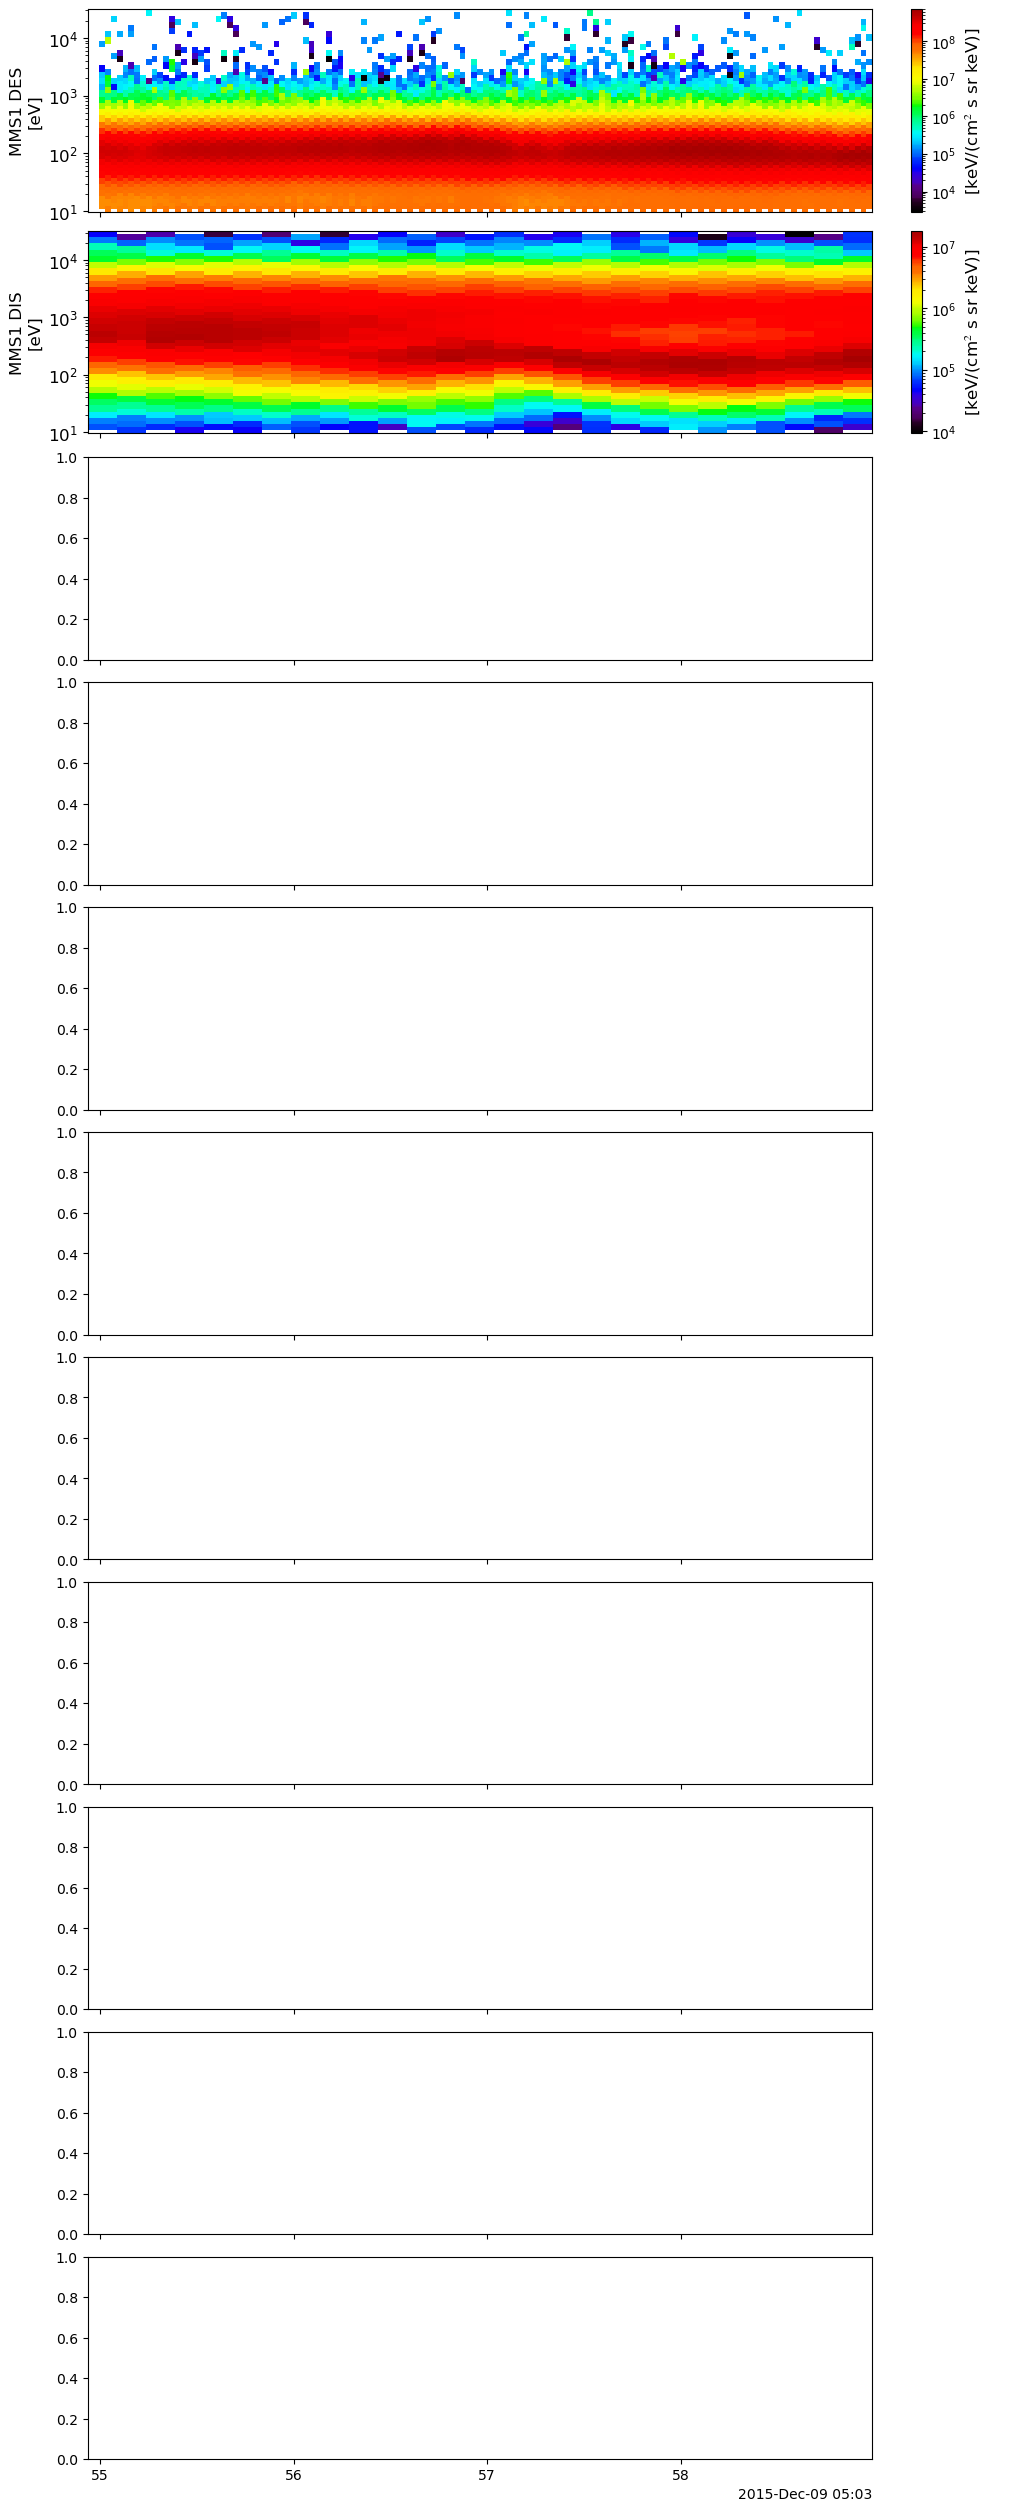

In [ ]:
fig, ax = plt.subplots(11, 1, figsize=(10, 25),  sharex=True, constrained_layout=True)
fig, ax0 = pyspedas.tplot('energy_e', fig = fig, axis = ax[0], display=False, return_plot_objects=True)
fig, ax1 = pyspedas.tplot('energy_i', fig = fig, axis = ax[1], display=False, return_plot_objects=True)
for im in ax0.get_images():
    if hasattr(im, "colorbar") and im.colorbar is not None:
        im.colorbar.set_label("")
ax0.set_ylabel('elec E\n[eV]')
ax1.set_ylabel('ion E\n[eV]')

# remove only the colorbar label for ax0
# ax0 is the axes returned by tplot





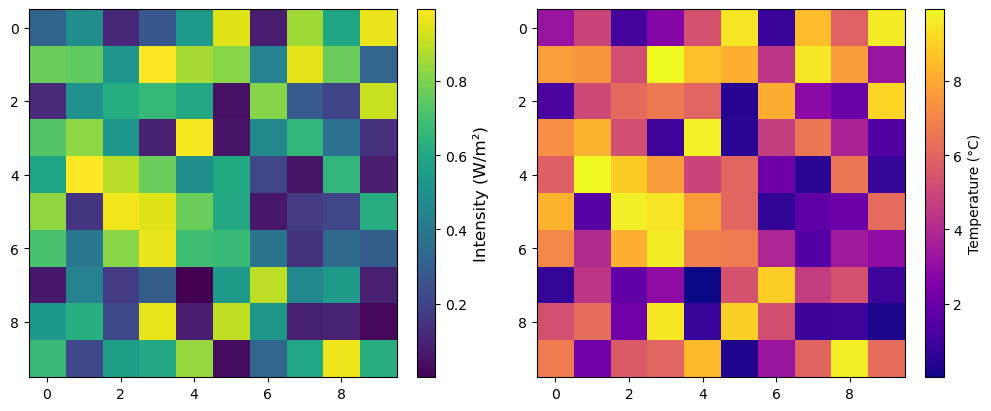

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 1x2 subplot layout
fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
data = np.random.rand(10, 10)

# Subplot 1
im1 = axs[0].imshow(data, cmap="viridis")
cbar1 = fig.colorbar(im1, ax=axs[0])
cbar1.set_label("Intensity (W/m²)", fontsize=12)  # Method 1

# Subplot 2
im2 = axs[1].imshow(data * 10, cmap="plasma")
# Method 2: Label defined inline
cbar2 = fig.colorbar(im2, ax=axs[1], label="Temperature (°C)") 

plt.show()


10-Aug-26 16:25:39: /opt/anaconda3/envs/phy/lib/python3.13/site-packages/executing/executing.py:713: DeprecationWarning: ast.Str is deprecated and will be removed in Python 3.14; use ast.Constant instead
  right=ast.Str(s=sentinel),

10-Aug-26 16:25:39: /opt/anaconda3/envs/phy/lib/python3.13/ast.py:602: DeprecationWarning: Constant.__init__ got an unexpected keyword argument 's'. Support for arbitrary keyword arguments is deprecated and will be removed in Python 3.15.
  return Constant(*args, **kwargs)

10-Aug-26 16:25:39: /opt/anaconda3/envs/phy/lib/python3.13/ast.py:602: DeprecationWarning: Attribute s is deprecated and will be removed in Python 3.14; use value instead
  return Constant(*args, **kwargs)

10-Aug-26 16:25:39: /opt/anaconda3/envs/phy/lib/python3.13/ast.py:602: DeprecationWarning: Constant.__init__ missing 1 required positional argument: 'value'. This will become an error in Python 3.15.
  return Constant(*args, **kwargs)



NameError: name 'bmag' is not defined

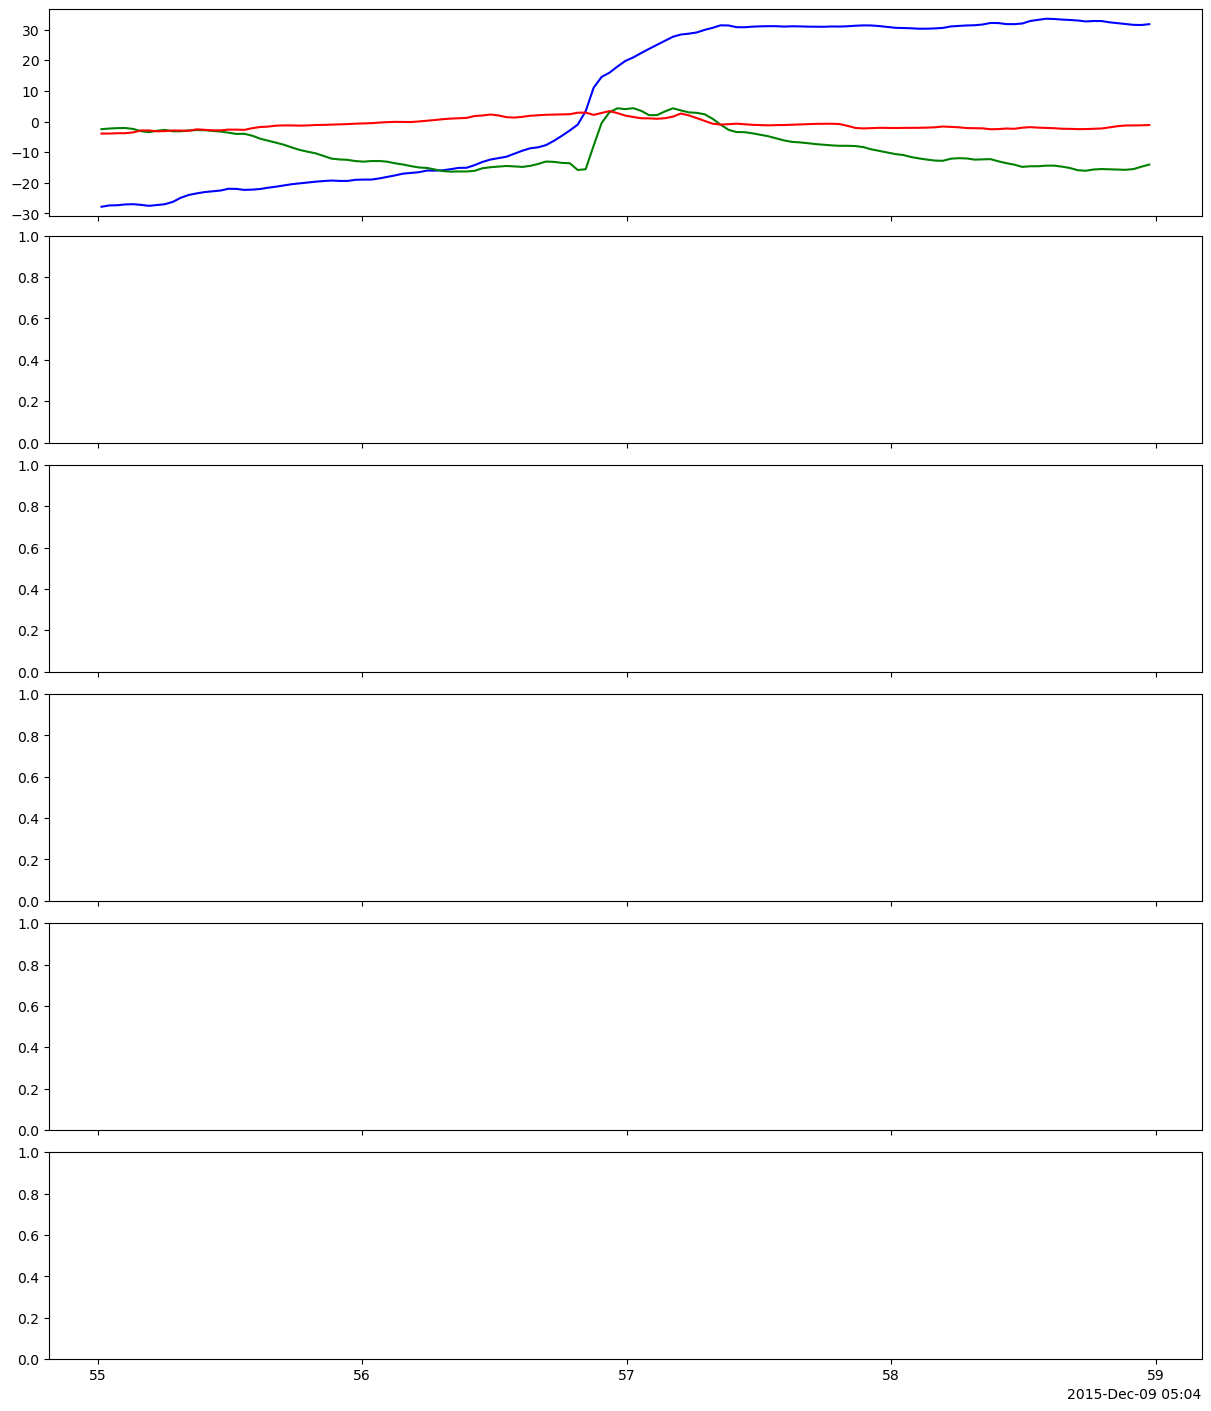

In [26]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

probe = '1'

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 6
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 14), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: electron bulkve_lmn profiles
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, bulk_vi_lmn, linewidth=1.5, label=["$U_{eL}$", "$U_{eM}$", "$U_{eN}$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$U_{iLMN}$ ($km/s$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: electron bulkve_lmn profiles
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, bulk_ve_lmn, linewidth=1.5, label=["$U_{eL}$", "$U_{eM}$", "$U_{eN}$"])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel("$U_{eLMN}$ ($km/s$)", fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Fifth subplot: ion and electron density
ax[3].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[3].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[3].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Sixth subplot: electron temp profiles
ax[4].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[4].plot(t_ax, tpara_e, linewidth=1.5, label=r'$T_{\parallel e}$')
ax[4].plot(t_ax, tperp_e, linewidth=1.5, label=r'$T_{\perp e}$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel(r'$T_e$(eV)', fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Seventh subplot: ion temp profiles
t_axi = time_datetime(ntime_i)
ax[5].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[5].plot(t_axi, tpara_i, linewidth=1.5, label=r'$T_{\parallel i}$')
ax[5].plot(t_axi, tperp_i, linewidth=1.5, label=r'$T_{\perp i}$')
ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[5].set_ylabel(r'$T_i$(eV)', fontsize=axs_label_fntsz)
ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame)


# # Fifth subplot: ion and electron density
# ax[4].set_prop_cycle(color=['blue', 'red']) # custom color cycle
# ax[4].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
# ax[4].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
# ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[4].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
# ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)


# # Second subplot: E vector in LMN coordinates
# ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
# ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
# ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)


# # Third subplot: E vector in FAC coordinates
# ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r'$E_{\perp_1}$', r'$E_{\perp_2}$', 
#         r'$E_{\parallel}$'])
# ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[2].set_ylabel('$E$ ($mV/m$)', fontsize=axs_label_fntsz)
# ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# # Fourth subplot: J.E' in FAC coordinates
# ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# # Pass 4 labels to match the 4 columns in jdotE_fac
# # Pass 4 labels to match the 4 columns in your array
# ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
#     label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
# ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
# ax[3].legend(fontsize=legend_fntsz, loc='upper left')

# # Fifth subplot: ion and electron density
# ax[4].set_prop_cycle(color=['blue', 'red']) # custom color cycle
# ax[4].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
# ax[4].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
# ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[4].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
# ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# # Sixth subplot: electron bulkve_lmn profiles
# ax[5].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[5].plot(t_ax, bulk_ve_lmn, linewidth=1.5, label=["$U_{eL}$", "$U_{eM}$", "$U_{eN}$"])
# ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[5].set_ylabel("$U_{eLMN}$ ($km/s$)", fontsize=axs_label_fntsz)
# ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame)


# Vertical reference lines
y_up = n_subplots + 0.38
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)

# Figure Title
suptitle = (f"Reconnection Event MMS{probe}")
fig.suptitle(suptitle, fontsize = 24)

plt.show()

# VDF Plot for t=62, the reconnection time

In [24]:
vdf_vol_fac.shape

(28, 28, 28, 133)

In [25]:
vdf_12, vdf_23, vdf_13 = fpc.slice3d_to_2d(vdf_vol_fac, time_slice=62)

In [26]:
vdf_fac_list = (vdf_12, vdf_13, vdf_23.T) # The order is xy, xz and zy
ax_pairs = ((x_fac, y_fac), (x_fac, z_fac), (z_fac, y_fac))
ax_lbls = [r"$v_{\perp 1}/v_{te}$", r"$v_{\perp 2}/v_{te}$", 
                           r"$v_{\parallel}/v_{te}$"]
axlabel_pairs = ((ax_lbls[0], ax_lbls[1]), (ax_lbls[0], ax_lbls[2]), 
                    (ax_lbls[2], ax_lbls[1])) # xy, xz, zy

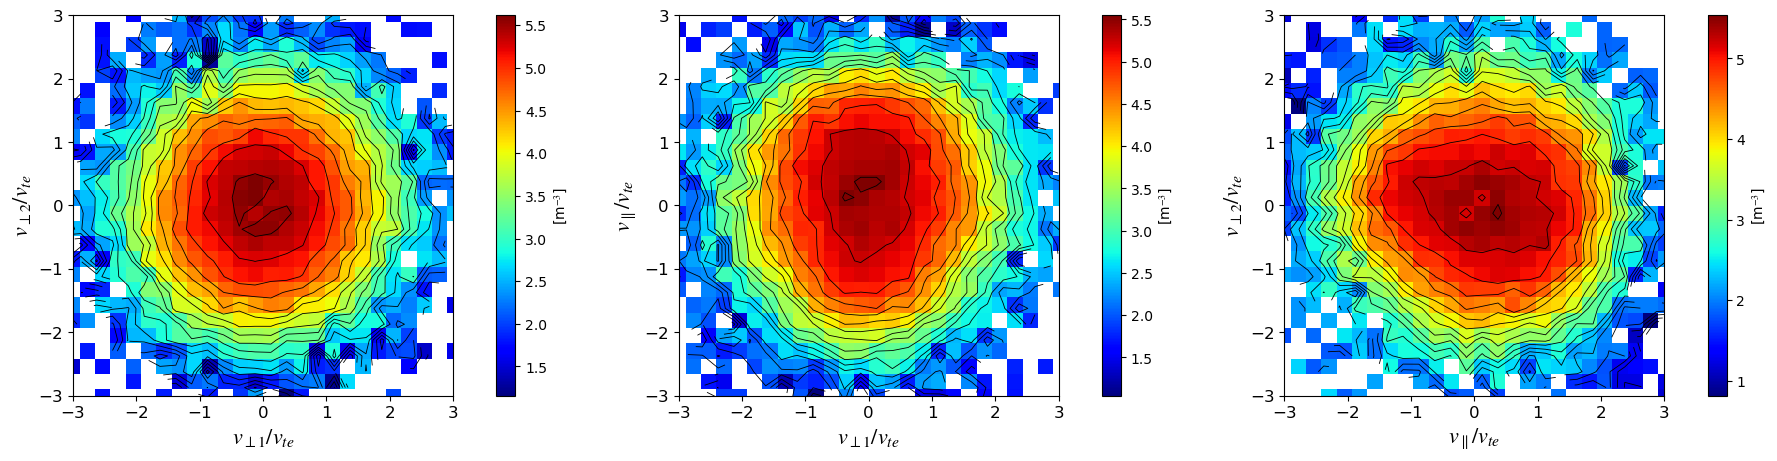

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100, constrained_layout=True)
axis_fntsz = 16
cbar_ht=0.047

for i in range(3):
    vmin, vmax = fpc.global_vmin_vmax_vdf(vdf_fac_list[i])
    ax1, ax2 = ax_pairs[i]
    xlabel, ylabel = axlabel_pairs[i]
    im1, _ = fpc.imagecont_vdf(ax1, ax2, vdf_fac_list[i], xlabel=xlabel, 
                ylabel=ylabel, ax=axes[i], vmin=vmin, vmax=vmax, 
                axis_fntsz=axis_fntsz)
    height, width = len(ax2), len(ax1)
    cbar = fig.colorbar(im1, ax=axes[i], fraction=cbar_ht*height/width, pad=0.08)
    cbar.set_label(r"[m$^{-3}$]")

# Folded E-parallel FPC plot for t=62, the reconnection event

In [39]:
c_vol_fac.shape, cz_folds_fac.shape

((3, 28, 28, 28, 133), (2, 28, 28, 133))

In [40]:
cz_12, cz_23, cz_13 = fpc.slice3d_to_2d(c_vol_fac[2], time_slice=62)

In [41]:
cz_fac_list = (cz_12, cz_folds_fac[0, :, :, 62], cz_folds_fac[1, :, :, 62]) # The order is xy, xz and zy   

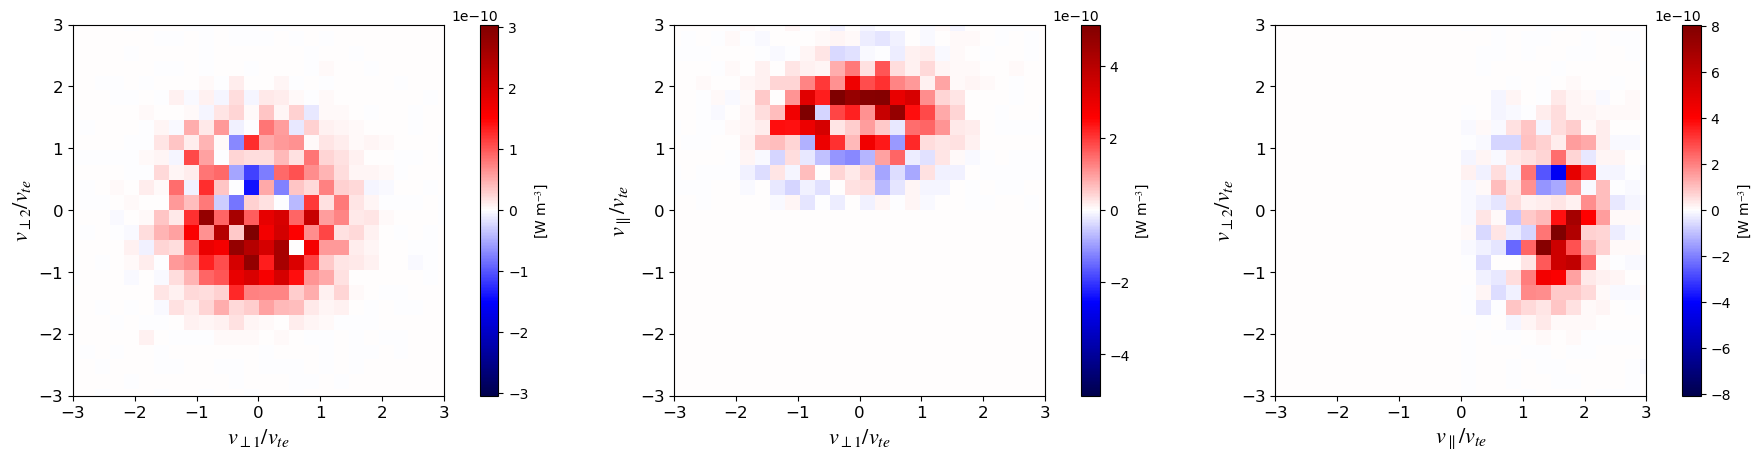

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100, constrained_layout=True)
axis_fntsz = 16
cbar_ht=0.047

for i in range(3):
    vmin, vmax = fpc.global_vmin_vmax_fpc(cz_fac_list[i])
    ax1, ax2 = ax_pairs[i]
    xlabel, ylabel = axlabel_pairs[i]
    im2, _ = fpc.imagecont_fpc(ax1, ax2, cz_fac_list[i], xlabel=xlabel, 
                ylabel=ylabel, ax=axes[i], vmin=vmin, vmax=vmax, 
                axis_fntsz=axis_fntsz)
    height, width = len(ax2), len(ax1)
    cbar = fig.colorbar(im2, ax=axes[i], fraction=cbar_ht*height/width, pad=0.005)
    cbar.set_label(r"[W m$^{-3}$]")


# Subtracted FPC integrated

In [6]:
data_dir = os.path.join("..", "data")
subtract_f0 = True
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile_df = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [7]:
hfile_df

'../data/mms1_brst_df_e_0.25_20151209_050355_050359.h5'

In [28]:
with h5py.File(hfile_df, 'r') as f:
    print(f['fac'].keys())

<KeysViewHDF5 ['Cprime_raw', 'Cprime_vol', 'JE_tot', 'bCprime_avg', 'bCprime_vol', 'binc', 'binc_n', 'bvdf_avg', 'bvdf_vol', 'c_avg', 'c_vol', 'edges', 'edges_n', 'evec_lor', 'npts_vol', 'npts_vol_cp', 'rot_mat', 'vdf_eq', 'vmap', 'vv']>


In [32]:
with h5py.File(hfile_df, "r") as f:
    ntime = f["meta"]["time"][:]
    c_vol_fac = f["fac"]["c_vol"][...]
    dvdf_vol_fac = f["fac"]["bvdf_vol"][...]
    vpar_fac = f["fac"]["binc_n"][:]
    vv_fac = f["fac"]["vv"][:] 

In [33]:
c_vol_fac.shape, vpar_fac.shape, dvdf_vol_fac.shape

((3, 28, 28, 28, 133), (28,), (28, 28, 28, 133))

Only selecting the parallel component of the FPC signature:

In [19]:
c_vol_fac_par = c_vol_fac[2]

In [20]:
c_vol_fac_par_t62 = c_vol_fac_par[:, :, :, 62]

In [21]:
c_vol_fac_par_t62.shape

(28, 28, 28)

integrating over both perp directions

In [22]:
c_line_fac_par_t62 = np.nansum(c_vol_fac_par_t62, axis=(0, 1))

In [23]:
c_line_fac_par_t62.shape

(28,)

In [24]:
vv_fac.shape

(3, 16384, 133)

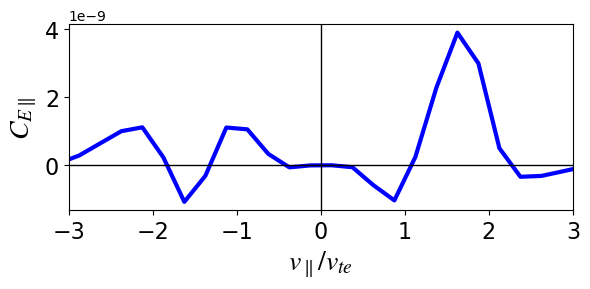

In [41]:
import matplotlib.pyplot as plt

# Assuming you have arrays:
# vpar_norm  → normalized parallel velocity (same scale as v_parallel/v_te)
# C_line     → integrated C_E_parallel array (shape = (28,))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(vpar_fac, c_line_fac_par_t62, color='blue', linewidth=3)

# Axis labels
ax.set_xlabel(r'$v_{\parallel}/v_{te}$', fontsize=20)
ax.set_ylabel(r'$C_{E\parallel}$', fontsize=20)

# Style tweaks to match the reference plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.tick_params(labelsize=16)
ax.set_xlim([-3, 3])

plt.tight_layout()
plt.show()

## Subtract vdf integrated
Selecting the subtracted vdf for t = 62

In [37]:
dvdf_vol_fac_t62 = dvdf_vol_fac[:, :, :, 62]

In [38]:
dvdf_vol_fac_t62.shape

(28, 28, 28)

Integrating over both perp directions

In [39]:
dvdf_line_fac_par_t62 = np.nansum(dvdf_vol_fac_t62, axis=(0, 1))

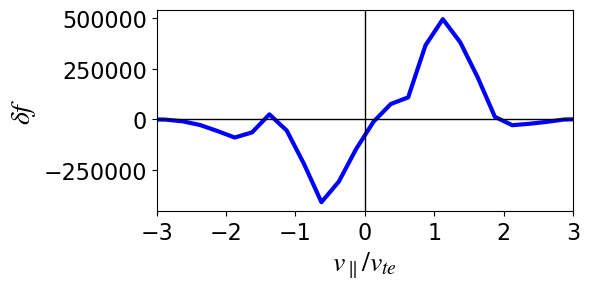

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have arrays:
# vpar_norm  → normalized parallel velocity (same scale as v_parallel/v_te)
# dvdf_line  → integrated df_parallel array (shape = (28,))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(vpar_fac, dvdf_line_fac_par_t62, color='blue', linewidth=3)

# Axis labels
ax.set_xlabel(r'$v_{\parallel}/v_{te}$', fontsize=20)
ax.set_ylabel(r'$\delta f$', fontsize=20)

# Style tweaks to match the reference plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.tick_params(labelsize=16)
ax.set_xlim([-3, 3])

plt.tight_layout()
plt.show()

# FPC plots at t=62
## Probe 1

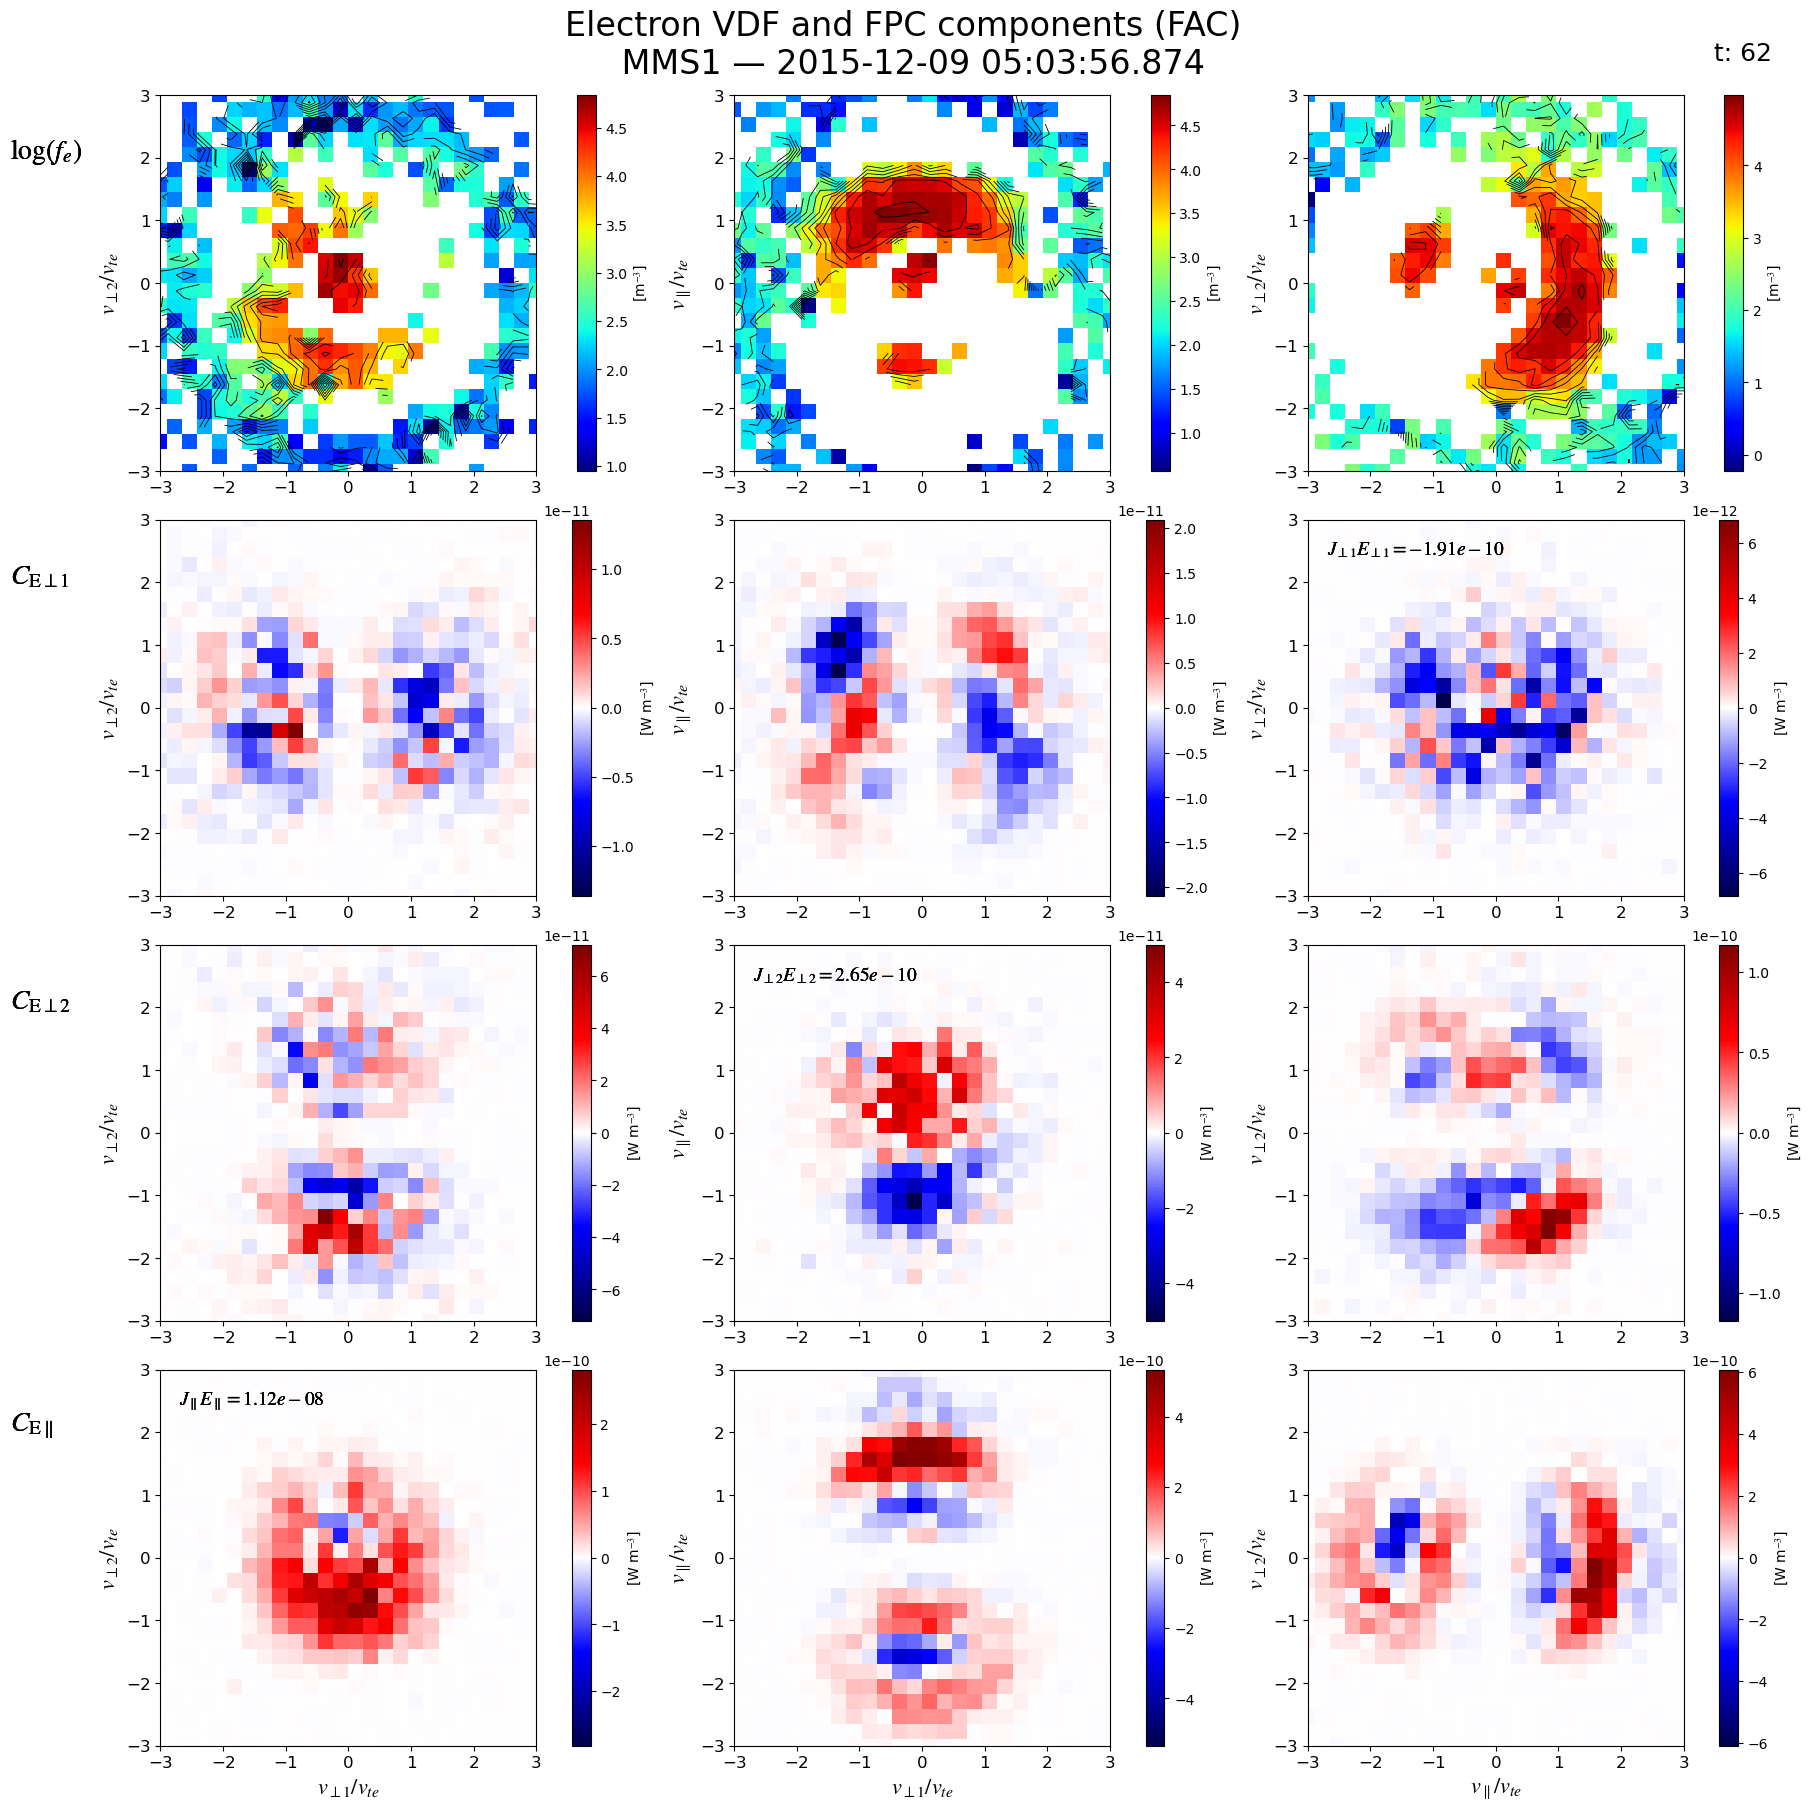

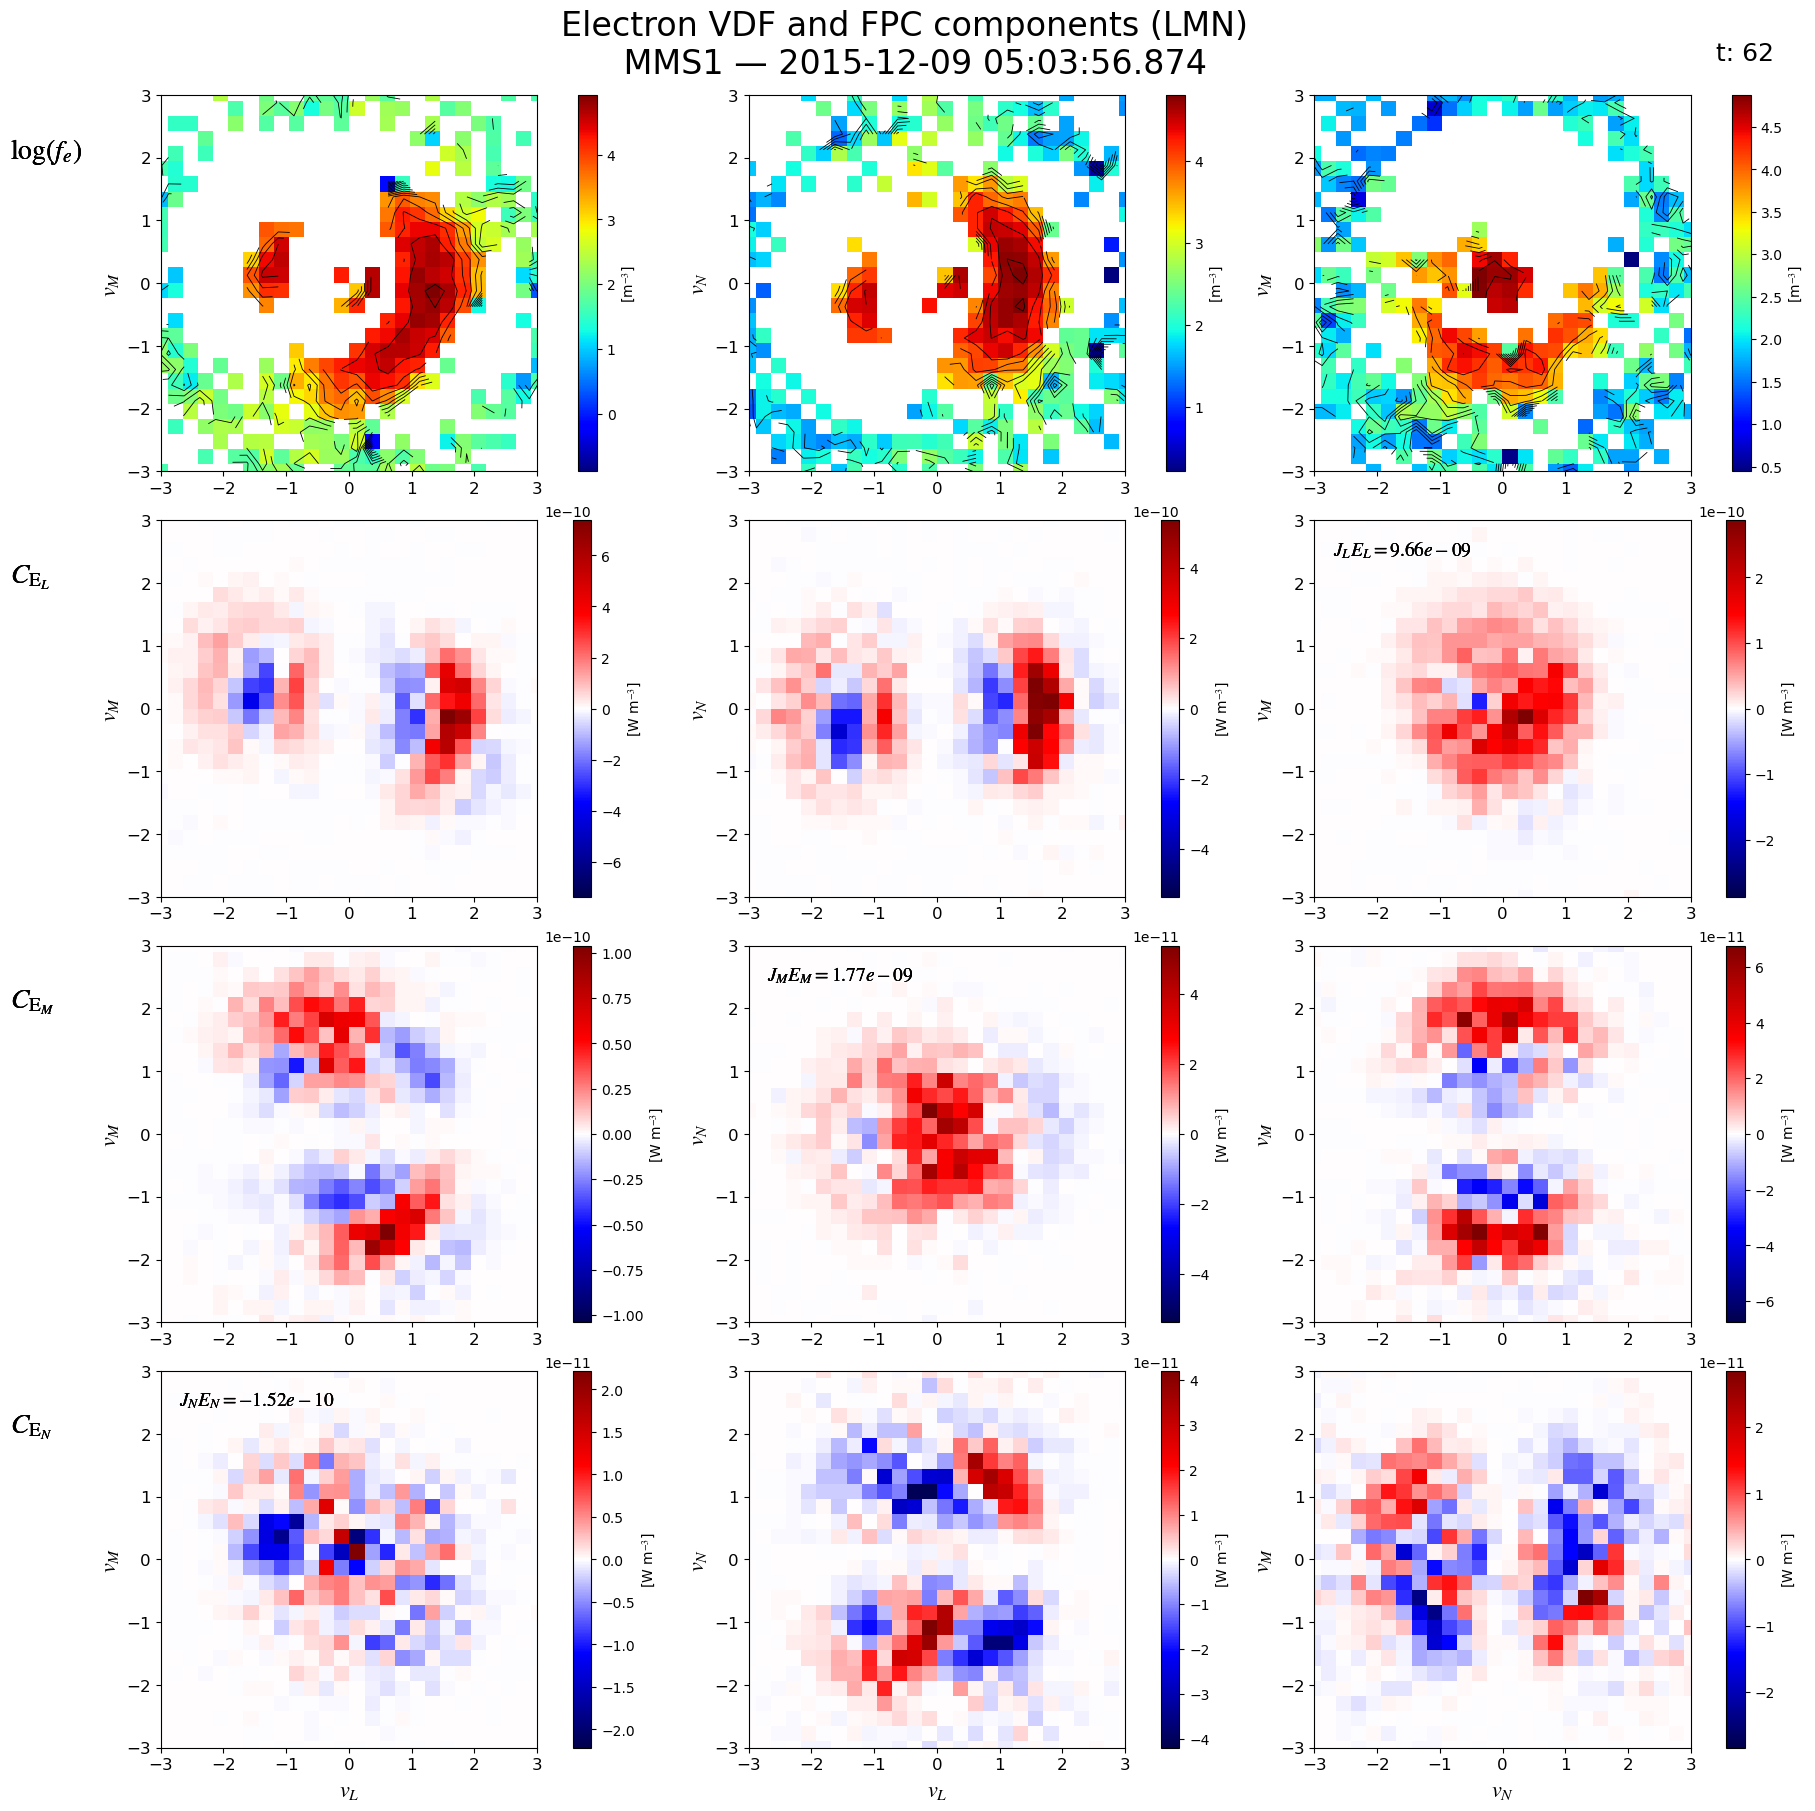

Files saved for time_index = 62


In [ ]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [62]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='1', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=False, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

## Probe 2

In [88]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='2', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=True, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

Files saved for time_index = 58
Files saved for time_index = 59
Files saved for time_index = 60
Files saved for time_index = 61
Files saved for time_index = 62
Files saved for time_index = 63
Files saved for time_index = 64


In [87]:
pwd

'/Users/rejohn/Library/CloudStorage/OneDrive-WestVirginiaUniversity/1 - Active Projects/MMS FPC/MMS FPC Analysis/FPC_mRx/scripts'

## Probe 3

In [89]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='3', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=True, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

Files saved for time_index = 58
Files saved for time_index = 59
Files saved for time_index = 60
Files saved for time_index = 61
Files saved for time_index = 62
Files saved for time_index = 63
Files saved for time_index = 64


## Probe 4

In [90]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='4', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=True, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

Files saved for time_index = 58
Files saved for time_index = 59
Files saved for time_index = 60
Files saved for time_index = 61
Files saved for time_index = 62
Files saved for time_index = 63
Files saved for time_index = 64
